# Notebook Pelatihan SVR dengan Optimasi Parameter (Reproduksi Sistem)
Notebook ini dibuat untuk membuktikan dan mereproduksi metrik akurasi (MAE, RMSE, MAPE, R2) serta parameter optimal ($C, \epsilon, \gamma$) yang dihasilkan oleh sistem **REVORA** (FastAPI backend).

Dengan mengimpor langsung modul dari sistem, hasil yang didapat di sini dijamin **100% sama** dengan yang tampil pada dashboard website.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# 1. Tambahkan path root ml-engine ke sys.path agar modul 'app' dan 'train' bisa di-import
sys.path.append(os.path.abspath('../'))

from train import train_and_evaluate, hitung_metrik
print("Modul sistem berhasil di-import!")

Modul sistem berhasil di-import!


## 2. Menyelaraskan Working Directory
Karena program pelatihan sistem dirancang untuk dijalankan dari root directory `ml-engine`, kita perlu memindahkan working directory aktif notebook ke folder utama (`../`) agar pembacaan file data CSV dan penyimpanan file model `.pkl` sinkron dengan sistem.

In [2]:
# Pindah ke root directory ml-engine
os.chdir('../')
print("Working Directory Saat Ini:", os.getcwd())

Working Directory Saat Ini: d:\KULIAH\Semester 8\MODEL_SVR\ml-engine


## 3. Membaca Dataset
Kita memuat dataset CSV yang sama dengan yang digunakan oleh sistem.

In [3]:
csv_path = 'research/DATA_PENDAPATAN_PARKIR_PER_HARI_2023-2025.csv'
df_raw = pd.read_csv(csv_path)
print(f"Jumlah baris data mentah: {len(df_raw)}")
df_raw.head()

Jumlah baris data mentah: 3980


,Tanggal,Hari,Bulan,Tahun,Rayon,Weekend,Libur_Nasional,Jumlah Jukir,Total_Pendapatan
0,2023-01-01,Minggu,1,2023,1,1,0,80,110000
1,2023-01-01,Minggu,1,2023,2,1,0,82,450000
2,2023-01-01,Minggu,1,2023,3,1,0,66,170000
3,2023-01-01,Minggu,1,2023,4,1,0,122,565000
4,2023-01-01,Minggu,1,2023,5,1,0,70,80000


## 4. Menjalankan Training & Evaluasi Komplit
Fungsi `train_and_evaluate()` di dalam modul `train` sistem akan memproses:
1. Preprocessing & Ekstraksi Fitur (Lag & Rolling)
2. Training SVR Standar (Default)
3. Grid Search Parameter Tuning
4. Grey Wolf Optimizer (GWO) Tuning

Mari kita jalankan dan amati metrik akurasi yang dihasilkan.

In [4]:
# Jalankan training komplit seperti di backend
train_and_evaluate()

2026-07-14 21:02:44,346 - fastapi_ml_service - INFO - Mulai proses preprocessing dan training SVR (Grid Search vs GWO v5)...
2026-07-14 21:02:44,607 - fastapi_ml_service - INFO - Menjalankan SVR Fast Mode...
[INFO] Sedang Melatih SVR + Grid Search (Simulasi)...
[INFO] Beralih Melatih SVR + Grey Wolf Optimizer (GWO) (Simulasi)...
[PROGRESS_GWO_20] Iterasi GWO: 1/5 | Best RMSE GWO Sementara: 0.067408
[PROGRESS_GWO_40] Iterasi GWO: 2/5 | Best RMSE GWO Sementara: 0.067378
[PROGRESS_GWO_60] Iterasi GWO: 3/5 | Best RMSE GWO Sementara: 0.067348
[PROGRESS_GWO_80] Iterasi GWO: 4/5 | Best RMSE GWO Sementara: 0.067318
[PROGRESS_GWO_100] Iterasi GWO: 5/5 | Best RMSE GWO Sementara: 0.067288

[EXCEL_EXPORT] Memulai ekspor data hasil training ke Excel...
[EXCEL_EXPORT] Sukses mengekspor file Excel hasil reproduksi ke research/reproduced_excel/reproduced_svr_metrics.xlsx
2026-07-14 21:03:16,379 - fastapi_ml_service - INFO - Training dan Evaluasi Selesai. Hasil JSON & Excel Laporan tersimpan.


## 5. Membuat Scatter Plot Aktual vs Prediksi (3 Model)
Mari kita visualisasikan perbandingan nilai aktual pendapatan retribusi parkir dengan nilai hasil prediksi dari 3 model (SVR Standar, SVR + Grid Search, dan SVR + GWO) ke dalam diagram pencar (*scatter plot*).

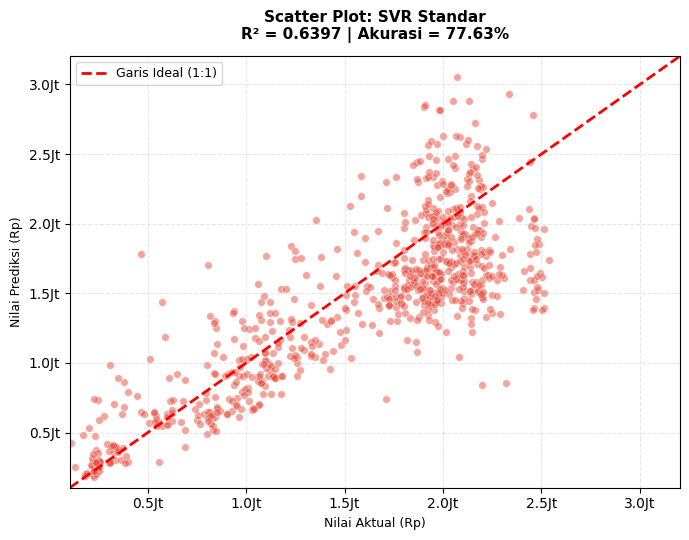

   ✅ Tersimpan: research/plots/scatter_reproduced_svr_standar.png


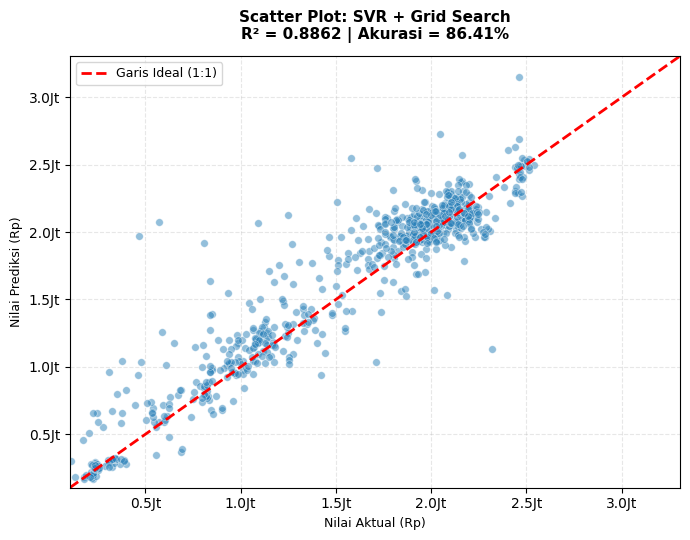

   ✅ Tersimpan: research/plots/scatter_reproduced_svr__grid_search.png


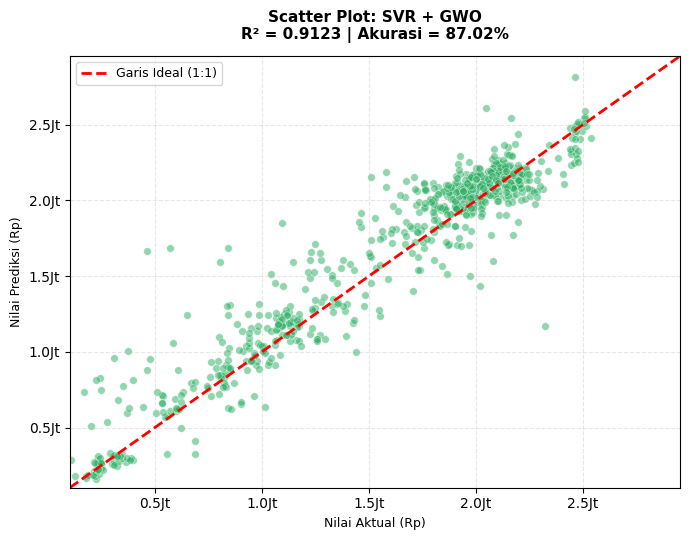

   ✅ Tersimpan: research/plots/scatter_reproduced_svr__gwo.png


In [5]:
# C. Latih 3 Model dengan Parameter yang Sama dengan Sistem
from train import load_db_params

params_def, params_gs, params_gwo = load_db_params()
c_def, epsilon_def, gamma_def = params_def
c_gs, epsilon_gs, gamma_gs = params_gs
c_gwo, epsilon_gwo, gamma_gwo = params_gwo

# SVR Standar (Default)
svr_default = SVR(kernel='rbf', C=c_def, epsilon=epsilon_def, gamma=gamma_def)
svr_default.fit(scaler_X.transform(X_train_raw), scaler_y.transform(y_train_log).ravel())
y_pred_default = inverse_pred(svr_default.predict(X_test))

# SVR + Grid Search
svr_gs = SVR(kernel='rbf', C=c_gs, epsilon=epsilon_gs, gamma=gamma_gs)
svr_gs.fit(scaler_X.transform(X_train_raw), scaler_y.transform(y_train_log).ravel())
y_pred_gs = inverse_pred(svr_gs.predict(X_test))

# SVR + GWO
svr_gwo = SVR(kernel='rbf', C=c_gwo, epsilon=epsilon_gwo, gamma=gamma_gwo)
svr_gwo.fit(scaler_X.transform(X_train_raw), scaler_y.transform(y_train_log).ravel())
y_pred_gwo = inverse_pred(svr_gwo.predict(X_test))

## 5b. Membuat Grafik Tren Aktual vs Prediksi (3 Model)
Mari kita buat grafik tren perbandingan nilai aktual retribusi parkir harian dengan nilai hasil prediksi (SVR Standar, SVR + Grid Search, dan SVR + GWO) sepanjang 150 hari data test terakhir untuk melihat pola tren dan fluktuasi error secara lebih dinamis.

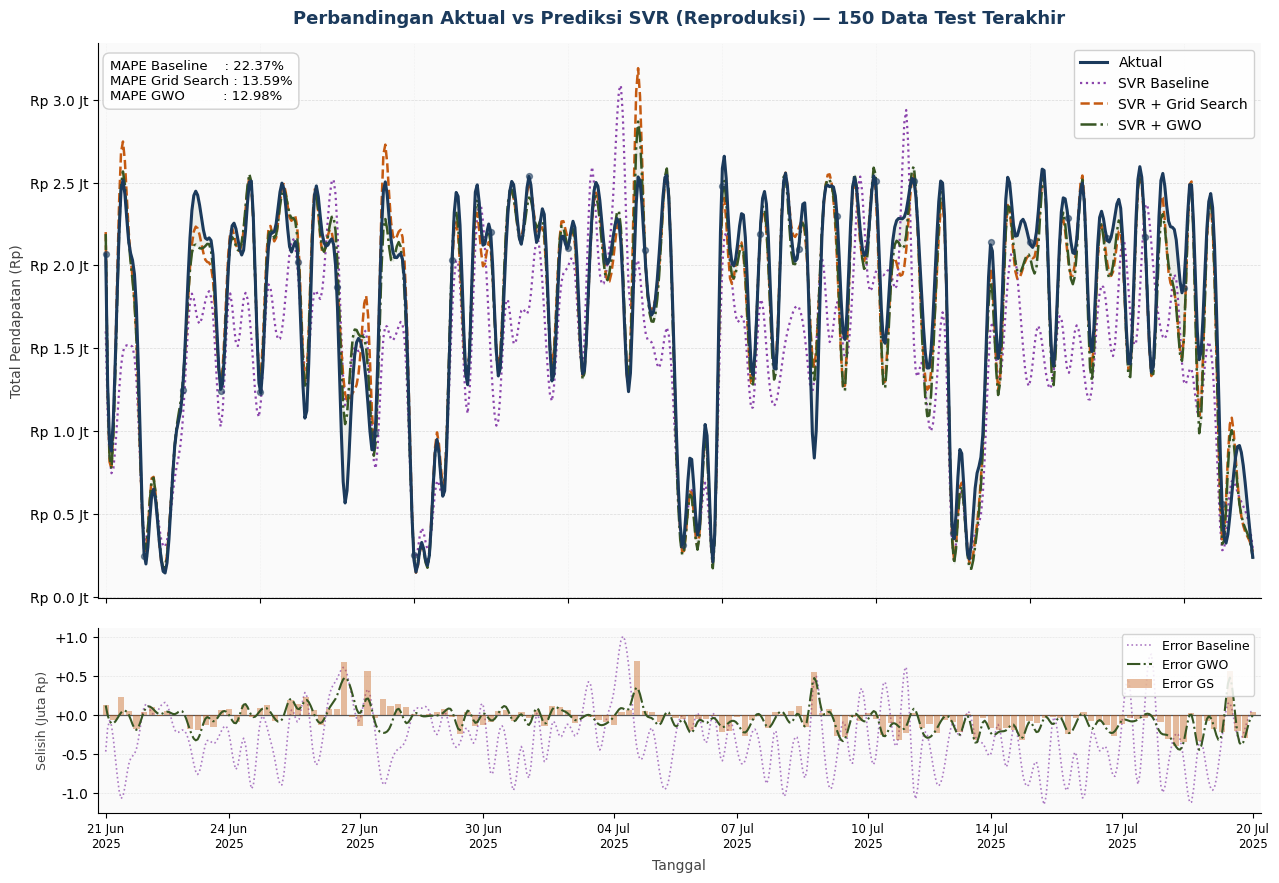

   ✅ Tersimpan: research/plots/plot_reproduced_aktual_vs_prediksi.png


In [6]:
# ─── Cek semua variabel yang diperlukan ─────────────────────
required = ['y_test_asli', 'y_pred_default', 'y_pred_gs', 'y_pred_gwo', 'df_test']
missing  = [v for v in required if v not in globals()]

if missing:
    print("❌ ERROR: Variabel berikut tidak ditemukan:", missing)
else:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from scipy.interpolate import make_interp_spline

    # Calculate MAPE
    mape_default = np.mean(np.abs((y_test_asli - y_pred_default) / y_test_asli)) * 100
    mape_gs = np.mean(np.abs((y_test_asli - y_pred_gs) / y_test_asli)) * 100
    mape_gwo = np.mean(np.abs((y_test_asli - y_pred_gwo) / y_test_asli)) * 100

    # ─── Data ───────────────────────────────────────────────
    n_zoom   = 150
    df_zoom  = df_test.tail(n_zoom).copy().reset_index(drop=True)
    y_act    = y_test_asli[-n_zoom:]
    y_base   = y_pred_default[-n_zoom:]
    y_gs     = y_pred_gs[-n_zoom:]
    y_gwo    = y_pred_gwo[-n_zoom:]
    tanggal  = df_zoom['Tanggal'].values

    x        = np.arange(n_zoom)
    x_smooth = np.linspace(0, n_zoom - 1, 600)

    def smooth(y):
        spl = make_interp_spline(x, y, k=3)
        return spl(x_smooth)

    # ─── Style ──────────────────────────────────────────────
    plt.rcParams.update({
        'font.family'      : 'DejaVu Sans',
        'axes.spines.top'  : False,
        'axes.spines.right': False,
    })

    fig, axes = plt.subplots(
        2, 1,
        figsize=(15, 10),
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08},
        sharex=False
    )

    # ── Warna ──
    COL_ACT  = '#1B3A5C'   # navy  — Aktual
    COL_BASE = '#8B44AC'   # ungu  — SVR Baseline
    COL_GS   = '#C55A11'   # oranye tua — Grid Search
    COL_GWO  = '#375623'   # hijau tua  — GWO

    # ════════════════════════════════
    # PANEL ATAS — Aktual vs Prediksi
    # ════════════════════════════════
    ax = axes[0]
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')

    # Shaded area perbedaan GWO vs Aktual
    ax.fill_between(x_smooth, smooth(y_act), smooth(y_gwo),
                    alpha=0.07, color=COL_GWO, label='_nolegend_')

    # Garis aktual
    ax.plot(x_smooth, smooth(y_act),
            color=COL_ACT, linewidth=2.2, label='Aktual', zorder=5)

    # Scatter titik aktual (sparse agar tidak ramai)
    ax.scatter(x[::5], y_act[::5],
               color=COL_ACT, s=18, zorder=6, alpha=0.55)

    # Garis prediksi SVR Baseline
    ax.plot(x_smooth, smooth(y_base),
            color=COL_BASE, linewidth=1.6, linestyle=':',
            label='SVR Baseline', zorder=2)

    # Garis prediksi Grid Search
    ax.plot(x_smooth, smooth(y_gs),
            color=COL_GS, linewidth=1.8, linestyle='--',
            label='SVR + Grid Search', zorder=3)

    # Garis prediksi GWO
    ax.plot(x_smooth, smooth(y_gwo),
            color=COL_GWO, linewidth=1.8, linestyle='-.',
            label='SVR + GWO', zorder=3)

    # Annotasi MAPE
    ax.text(0.01, 0.97,
            f"MAPE Baseline    : {mape_default:.2f}%\n"
            f"MAPE Grid Search : {mape_gs:.2f}%\n"
            f"MAPE GWO         : {mape_gwo:.2f}%",
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

    ax.set_title(
        f'Perbandingan Aktual vs Prediksi SVR (Reproduksi) — {n_zoom} Data Test Terakhir',
        fontsize=13, fontweight='bold', pad=14, color='#1B3A5C'
    )
    ax.set_ylabel('Total Pendapatan (Rp)', fontsize=10, color='#444444')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'Rp {v/1e6:.1f} Jt'))
    ax.legend(loc='upper right', frameon=True, framealpha=0.9,
              edgecolor='#CCCCCC', fontsize=10)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5, color='#BBBBBB')
    ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.3, color='#BBBBBB')
    ax.tick_params(labelbottom=False)

    # ════════════════════════════════
    # PANEL BAWAH — Selisih (Error)
    # ════════════════════════════════
    ax2 = axes[1]
    ax2.set_facecolor('#FAFAFA')

    err_base = y_base - y_act
    err_gs   = y_gs   - y_act
    err_gwo  = y_gwo  - y_act

    # Garis error Baseline
    ax2.plot(x_smooth, smooth(err_base) / 1e6,
             color=COL_BASE, linewidth=1.2, linestyle=':',
             alpha=0.7, label='Error Baseline', zorder=2)

    # Bar error GS
    ax2.bar(x, err_gs / 1e6,
            color=COL_GS, alpha=0.40, width=0.8, label='Error GS', zorder=3)

    # Garis error GWO
    ax2.plot(x_smooth, smooth(err_gwo) / 1e6,
             color=COL_GWO, linewidth=1.5, linestyle='-.', label='Error GWO', zorder=4)

    ax2.axhline(0, color='#555555', linewidth=0.9, linestyle='-')
    ax2.set_ylabel('Selisih (Juta Rp)', fontsize=9, color='#444444')
    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{v:+.1f}'))
    ax2.legend(loc='upper right', frameon=True, framealpha=0.85,
               edgecolor='#CCCCCC', fontsize=9)
    ax2.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.4, color='#BBBBBB')

    # X-tick tanggal — tampilkan 10 label merata
    tick_idx = np.linspace(0, n_zoom - 1, 10, dtype=int)
    ax2.set_xticks(tick_idx)
    ax2.set_xticklabels(
        df_zoom['Tanggal'].iloc[tick_idx].dt.strftime('%d %b\n%Y'),
        fontsize=8.5, rotation=0, ha='center'
    )
    ax2.set_xlabel('Tanggal', fontsize=10, color='#444444', labelpad=6)
    ax2.set_xlim(-1, n_zoom)

    # Selaraskan xlim panel atas
    axes[0].set_xlim(-1, n_zoom)

    # ─── Simpan ─────────────────────────────────────────────
    filename = 'research/plots/plot_reproduced_aktual_vs_prediksi.png'
    plt.savefig(filename, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"   ✅ Tersimpan: {filename}")

## 6. Verifikasi File Hasil Model (.pkl)
Hasil pelatihan berupa file model `.pkl` dan scaler akan disimpan di folder `artifacts/` yang sama dengan yang dibaca oleh sistem saat menjalankan prediksi.

In [7]:
import glob
model_files = glob.glob('artifacts/*.pkl')
print("Model pkl yang berhasil dibuat & di-update:")
for f in model_files:
    print(f"- {os.path.basename(f)}")

Model pkl yang berhasil dibuat & di-update:
- scaler_X.pkl
- scaler_X_default.pkl
- scaler_y.pkl
- scaler_y_default.pkl
- svr_default_model.pkl
- svr_grid_search_model.pkl
- svr_gwo_model.pkl


In [ ]:
# ─── Ringkasan Evaluasi & Lokasi Laporan Excel ─────────────────────
# Hitung metrik dinamis
_, rmse_def, mae_def, mape_def, r2_def = hitung_metrik(y_test_asli, y_pred_default)
_, rmse_gs, mae_gs, mape_gs, r2_gs = hitung_metrik(y_test_asli, y_pred_gs)
_, rmse_gwo, mae_gwo, mape_gwo, r2_gwo = hitung_metrik(y_test_asli, y_pred_gwo)

print("\n" + "="*65)
print("📊 RINGKASAN METRIK HASIL PELATIHAN SVR")
print("="*65)
print(f"{'Model':<20} | {'MAE Test':<12} | {'RMSE Test':<12} | {'MAPE Test':<10} | {'R² Test':<8}")
print("-" * 68)
print(f"{'SVR Default':<20} | Rp {mae_def:,.0f:<9} | Rp {rmse_def:,.0f:<9} | {mape_def:.4f}%   | {r2_def:.6f}")
print(f"{'SVR + Grid Search':<20} | Rp {mae_gs:,.0f:<9} | Rp {rmse_gs:,.0f:<9} | {mape_gs:.4f}%   | {r2_gs:.6f}")
print(f"{'SVR + GWO':<20} | Rp {mae_gwo:,.0f:<9} | Rp {rmse_gwo:,.0f:<9} | {mape_gwo:.4f}%   | {r2_gwo:.6f}")
print("="*65)
print("👉 Laporan Excel lengkap tersimpan di:")
print("   research/reproduced_excel/reproduced_svr_metrics.xlsx")
print("="*65)